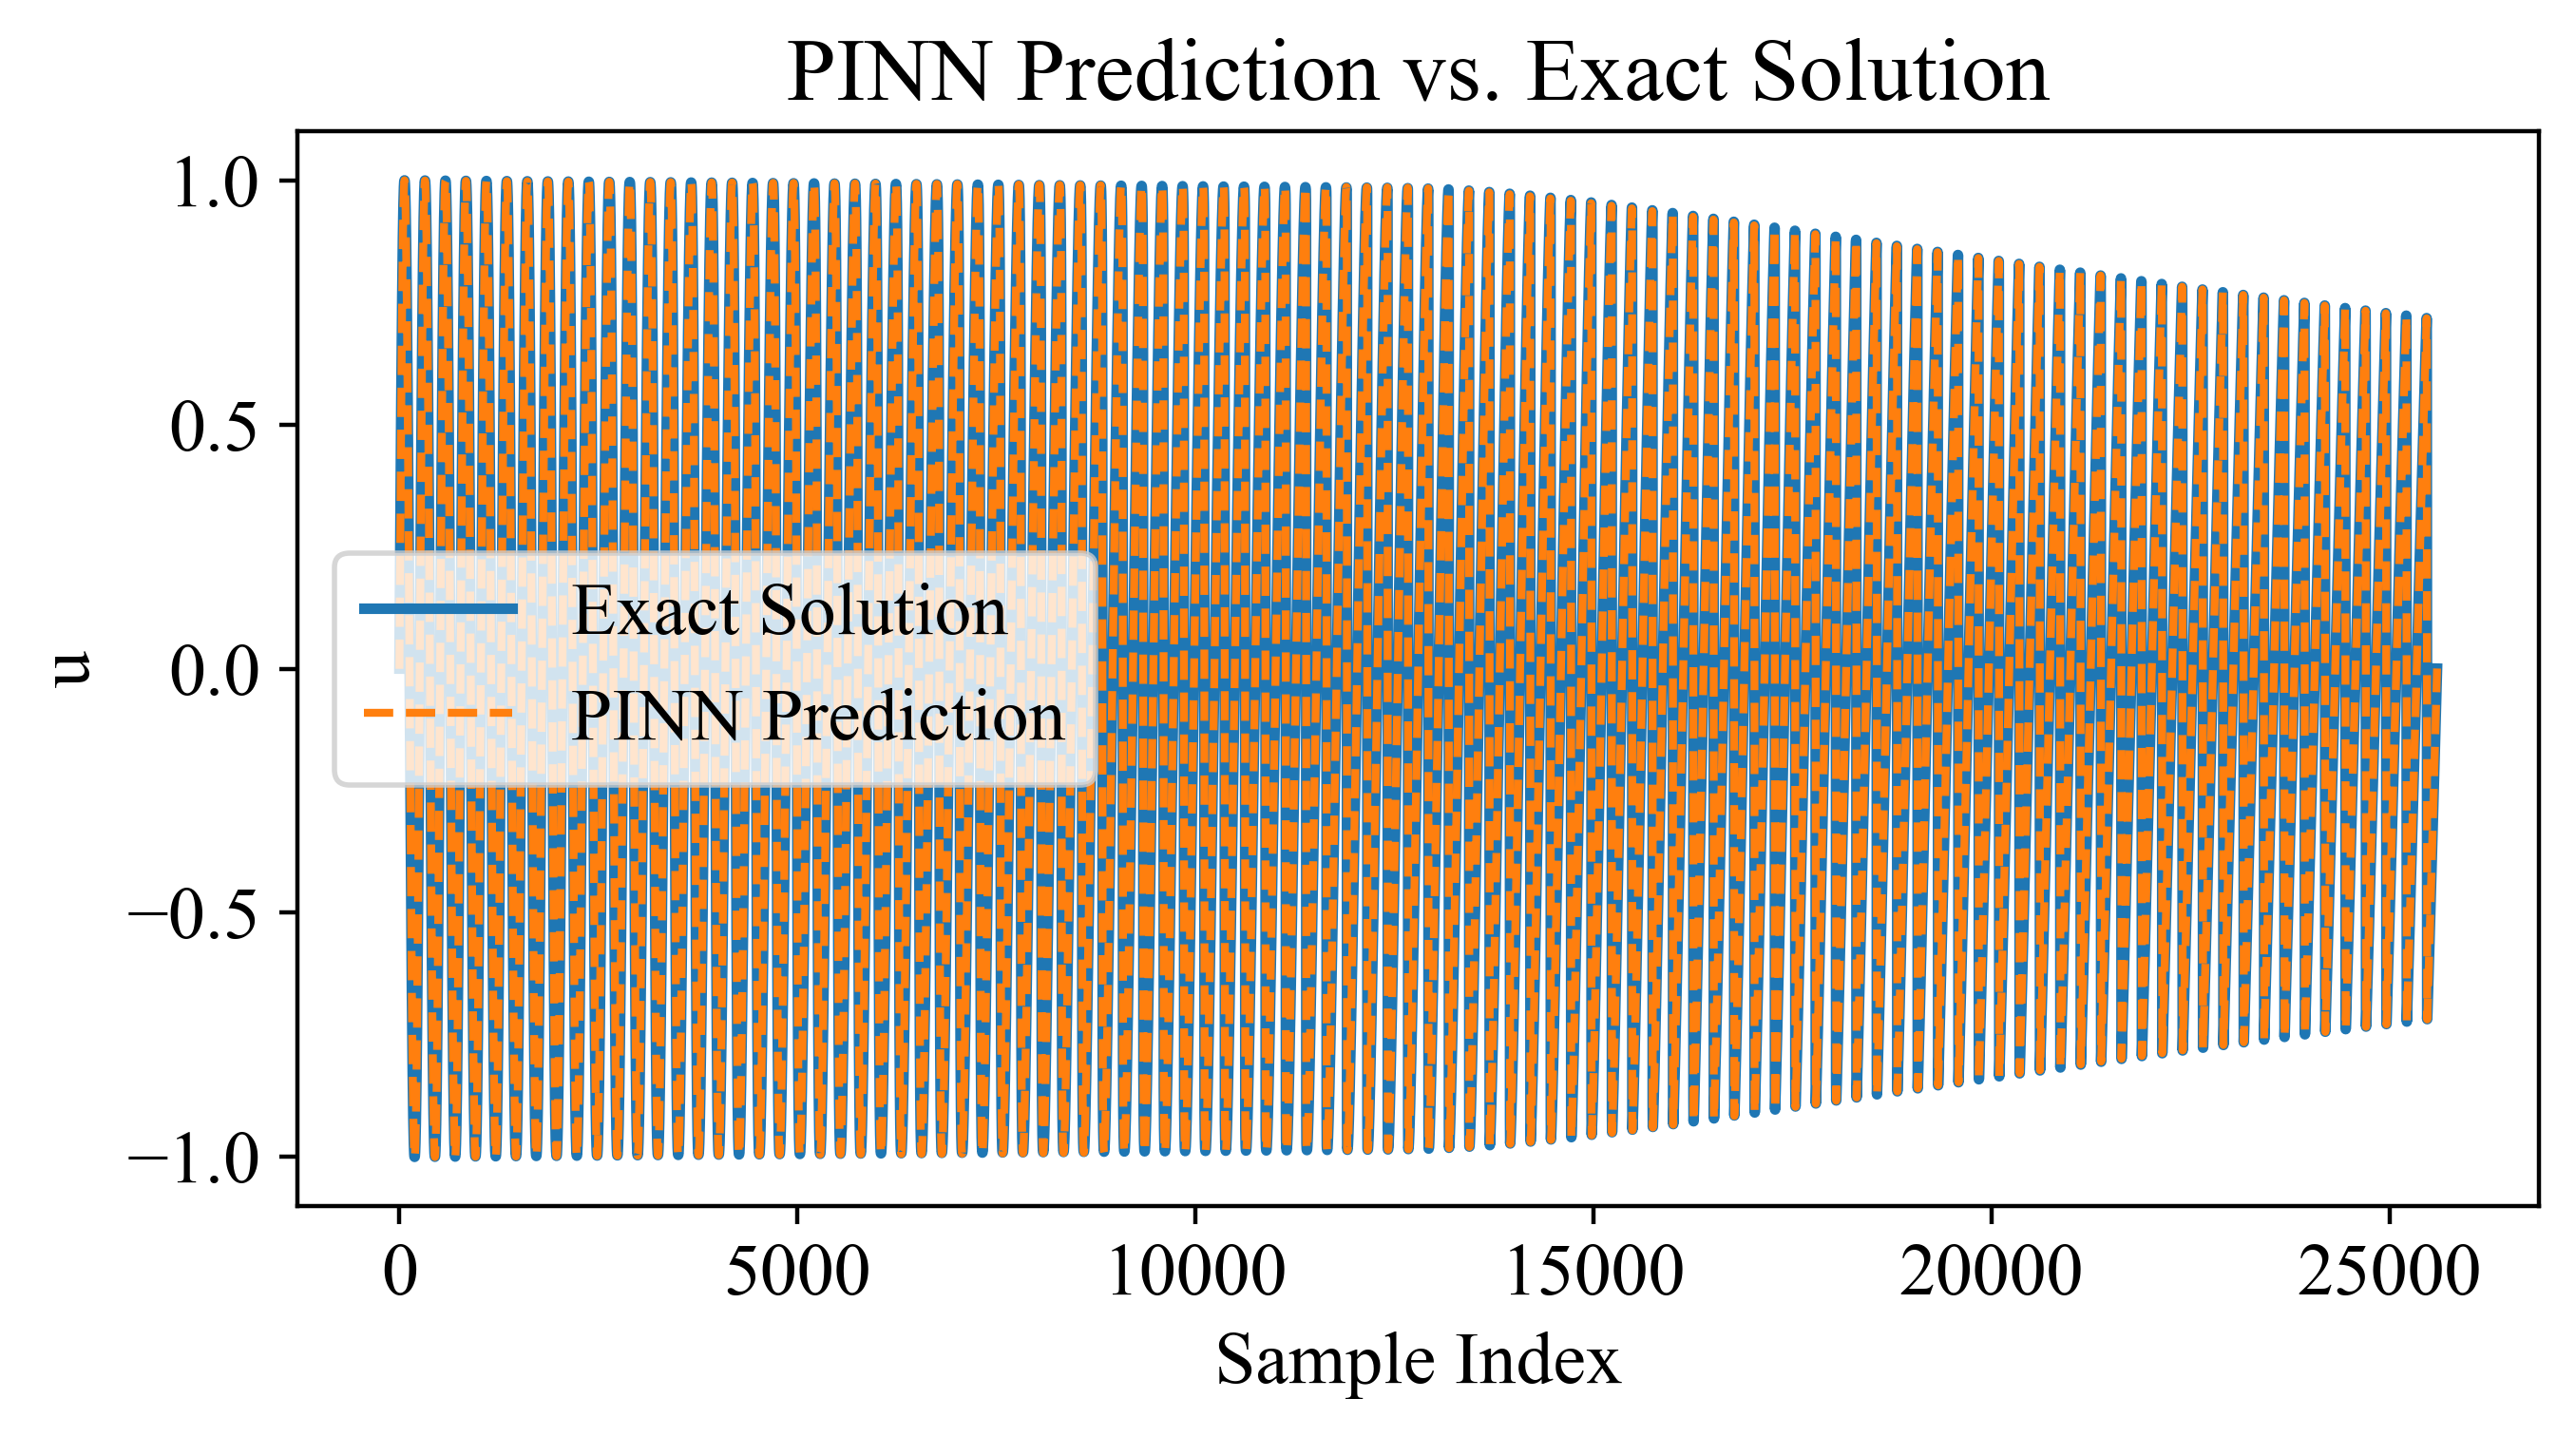

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 파일 경로에 맞게 수정하세요
exact = np.loadtxt('./results/4_10/LPA/exact_LPA.txt', delimiter=',')
prediction = np.loadtxt('./results/4_10/LPA/prediction_LPA.txt', delimiter=',')

plt.figure(figsize=(7,4))
plt.plot(exact, label='Exact Solution', linewidth=2)
plt.plot(prediction, label='PINN Prediction', linestyle='--')
plt.xlabel('Sample Index')
plt.ylabel('u')
plt.legend()
plt.title('PINN Prediction vs. Exact Solution')
plt.tight_layout()
plt.show()

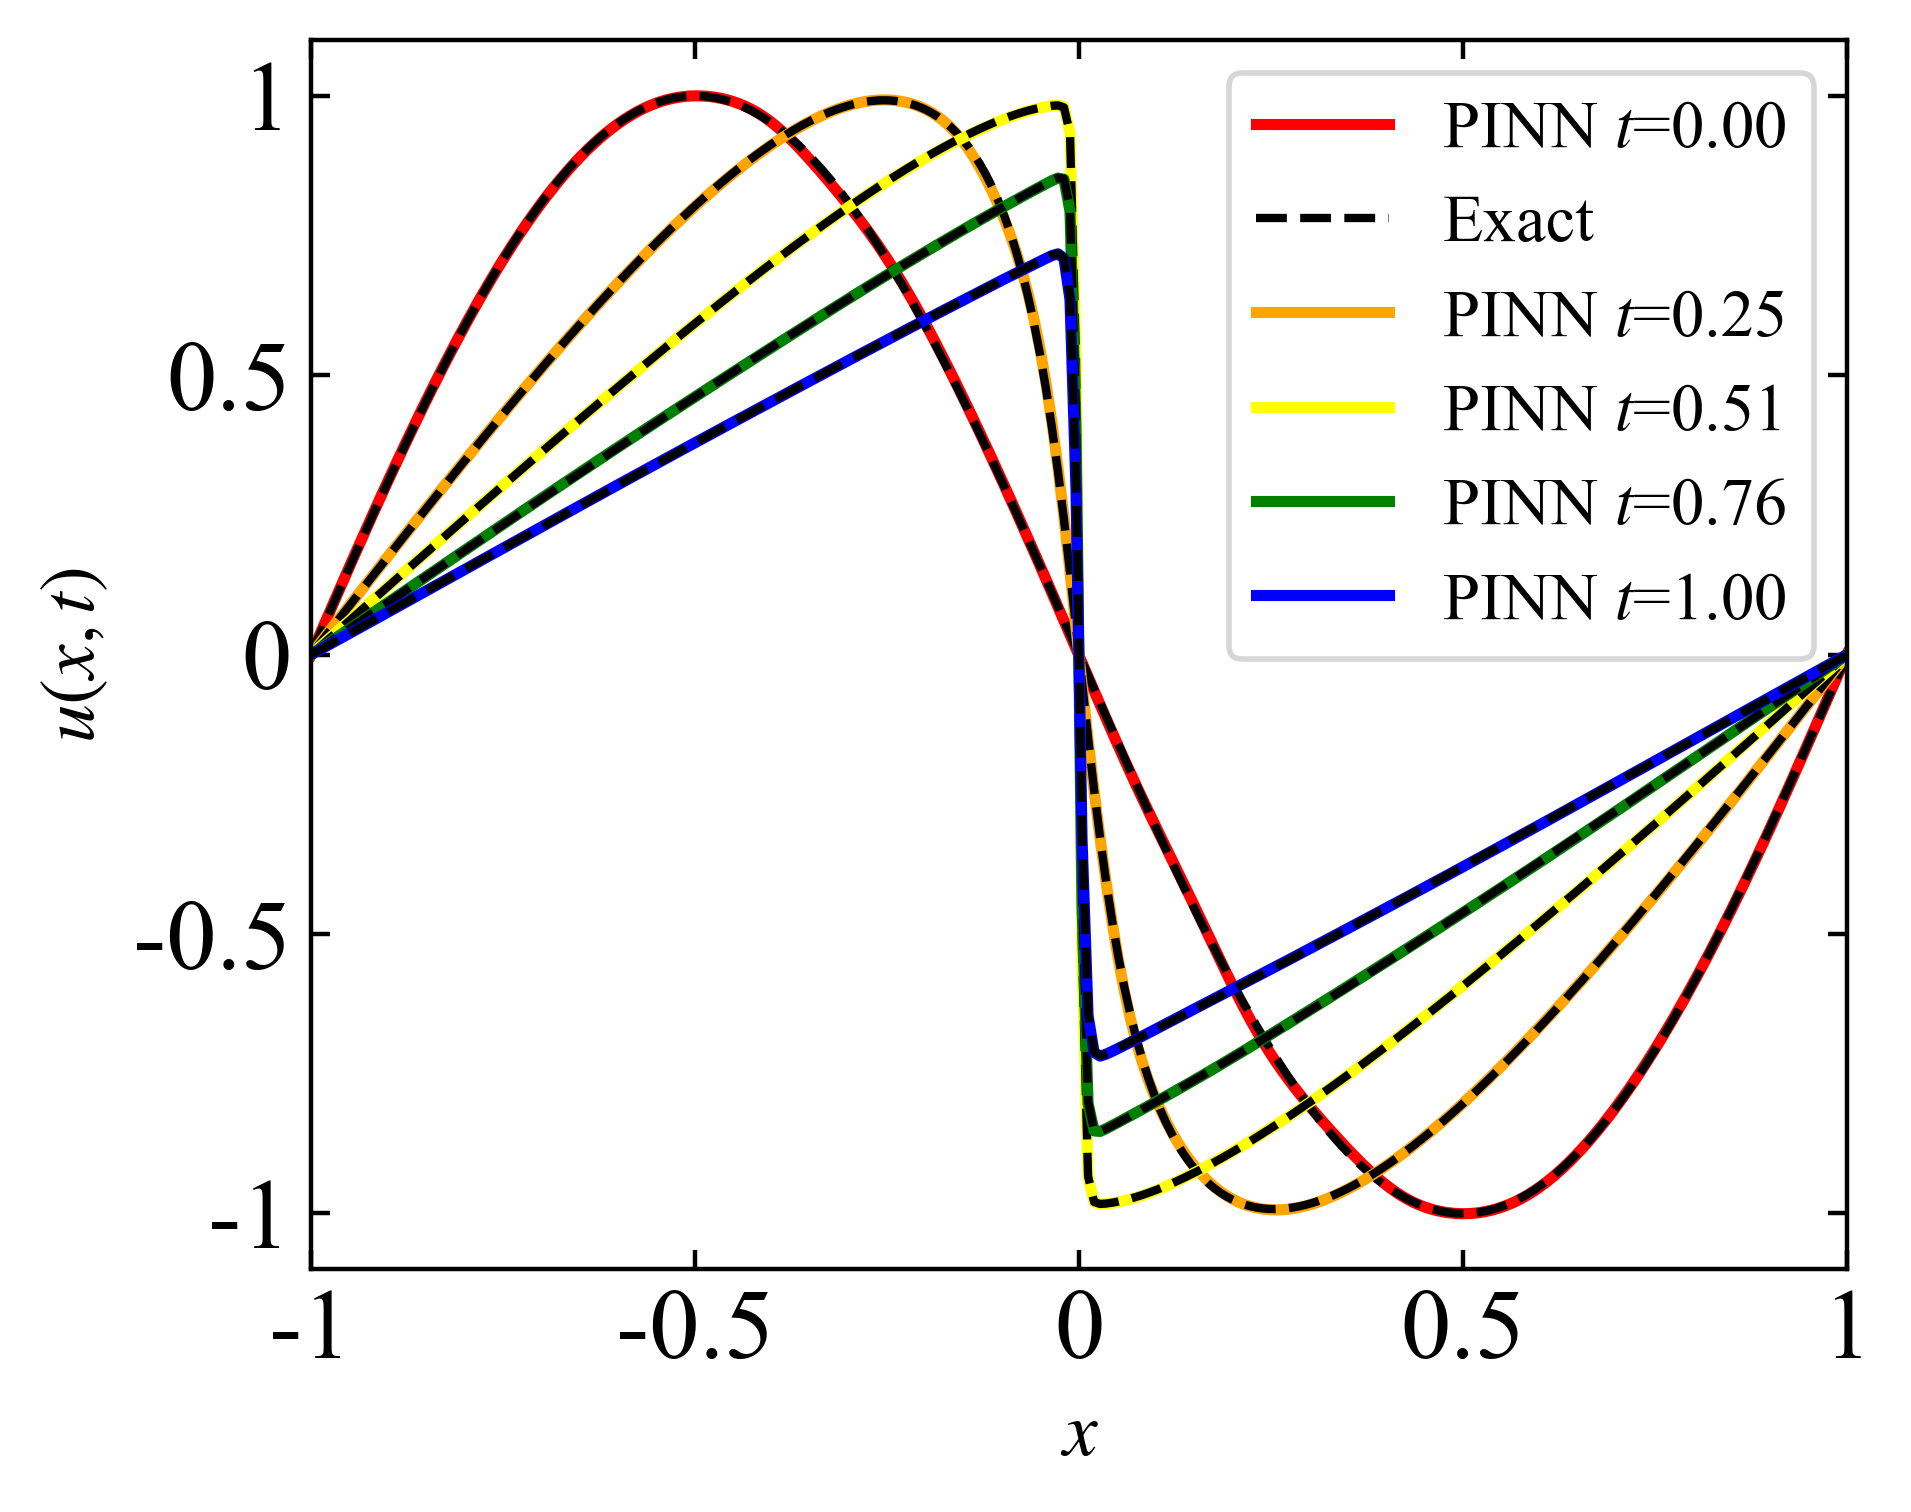

In [5]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.size'] = 14
mpl.rcParams['figure.dpi'] = 400

exact = np.loadtxt('./results/4_10/LPA/exact_LPA.txt', delimiter=',').flatten()
prediction = np.loadtxt('./results/4_10/LPA/prediction_LPA.txt', delimiter=',').flatten()

nx, nt = 256, 100

exact = exact.reshape(nt, nx)
prediction = prediction.reshape(nt, nx)

x = np.linspace(-1, 1, nx)
t_list = [0, 25, 50, 75, 99]  # 예시 인덱스

def no_dot_if_int(x, pos):
    if float(x).is_integer():
        return f"{int(x)}"
    else:
        return f"{x:g}"

formatter = FuncFormatter(no_dot_if_int)

plt.figure(figsize=(5,4))
colors = ['red', 'orange','yellow', 'green', 'blue']#plt.cm.coolwarm(np.linspace(0, 1, len(t_list)))  # 컬러맵 (PINN 전용)

for idx, i in enumerate(t_list):
    # PINN 예측: 컬러 실선
    plt.plot(x, prediction[i], color=colors[idx], linewidth=2, label=f'PINN $t$={i/(nt-1):.2f}')
    # Exact: 검정 점선
    plt.plot(x, exact[i], color='black', linestyle='--', linewidth=1.5, label=None if idx else 'Exact')

plt.xlabel('$x$', fontsize=14)
plt.ylabel('$u(x,t)$', fontsize=14)
plt.xlim(-1, 1)
plt.ylim(-1.1, 1.1)
plt.tick_params(axis='both', which='major', direction='in', labelsize=18, top=True, right=True)
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Legend: PINN만, Exact은 1개만(중복 제거)
handles, labels = plt.gca().get_legend_handles_labels()
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))
plt.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.show()

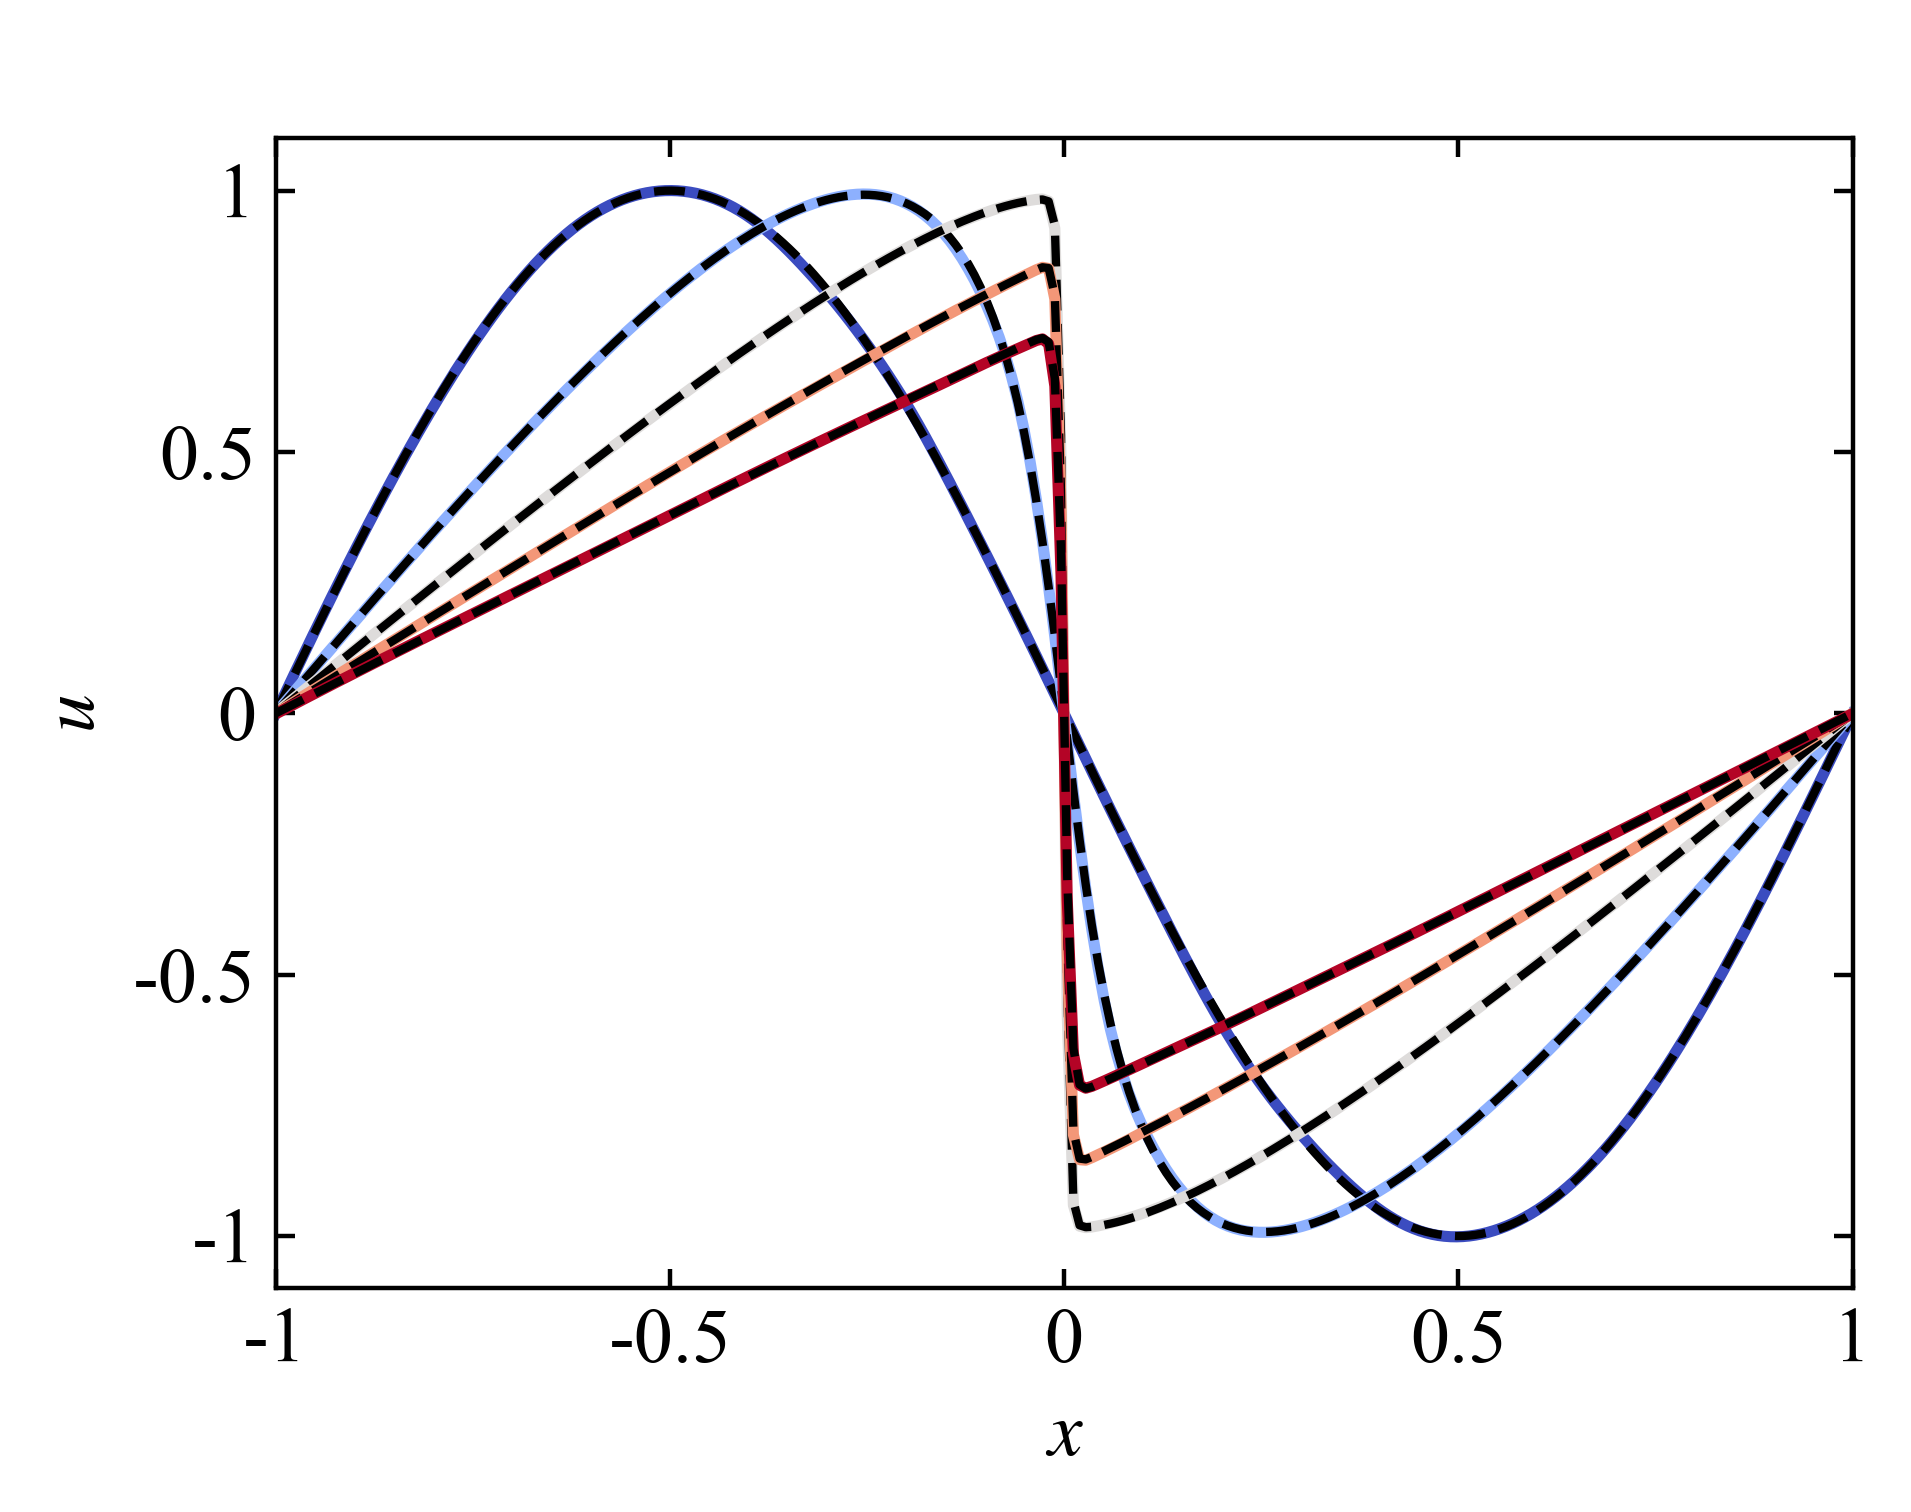

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
from collections import OrderedDict

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.size'] = 14
mpl.rcParams['figure.dpi'] = 400

exact = np.loadtxt('./results/4_10/LPA/exact_LPA.txt', delimiter=',').flatten()
prediction = np.loadtxt('./results/4_10/LPA/prediction_LPA.txt', delimiter=',').flatten()

nx, nt = 256, 100
exact = exact.reshape(nt, nx)
prediction = prediction.reshape(nt, nx)

x = np.linspace(-1, 1, nx)
t_list = [0, 25, 50, 75, 99]  # 예시 인덱스

def no_dot_if_int(v, pos):
    return f"{int(v)}" if float(v).is_integer() else f"{v:g}"
formatter = FuncFormatter(no_dot_if_int)

# ── Colormap 설정 ───────────────────────────────────
cmap_name = 'coolwarm'  # 'viridis', 'turbo', 'cividis', 'plasma' 등
cmap = plt.get_cmap(cmap_name)
norm = mpl.colors.Normalize(vmin=0, vmax=nt-1)     # t 인덱스 정규화
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.figure(figsize=(5,4))

for i in t_list:
    color = cmap(norm(i))
    # PINN 예측: colormap 기반 실선 (라벨 X → colorbar로 설명)
    plt.plot(x, prediction[i], color=color, linewidth=2)
    # Exact: 검정 점선 (한 번만 라벨)
    plt.plot(x, exact[i], color='black', linestyle='--', linewidth=1.5,
             label='Exact' if i == t_list[0] else None)

plt.xlabel('$x$', fontsize=14)
plt.ylabel('$u$', fontsize=14)
plt.xlim(-1, 1)
plt.ylim(-1.1, 1.1)
plt.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Legend: Exact만 표시
handles, labels = plt.gca().get_legend_handles_labels()
by_label = OrderedDict(zip(labels, handles))
if by_label:
    plt.legend(by_label.values(), by_label.keys(), fontsize=12, loc='best', frameon=False).remove()

# Colorbar: t 인덱스를 정규화된 t로 라벨링
#cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.01)
#cbar.set_label('t (normalized)', rotation=90)
#cbar.set_ticks(t_list)
#cbar.set_ticklabels([f'{i/(nt-1):.2f}' for i in t_list])
plt.title(' ')
plt.tight_layout()
plt.show()


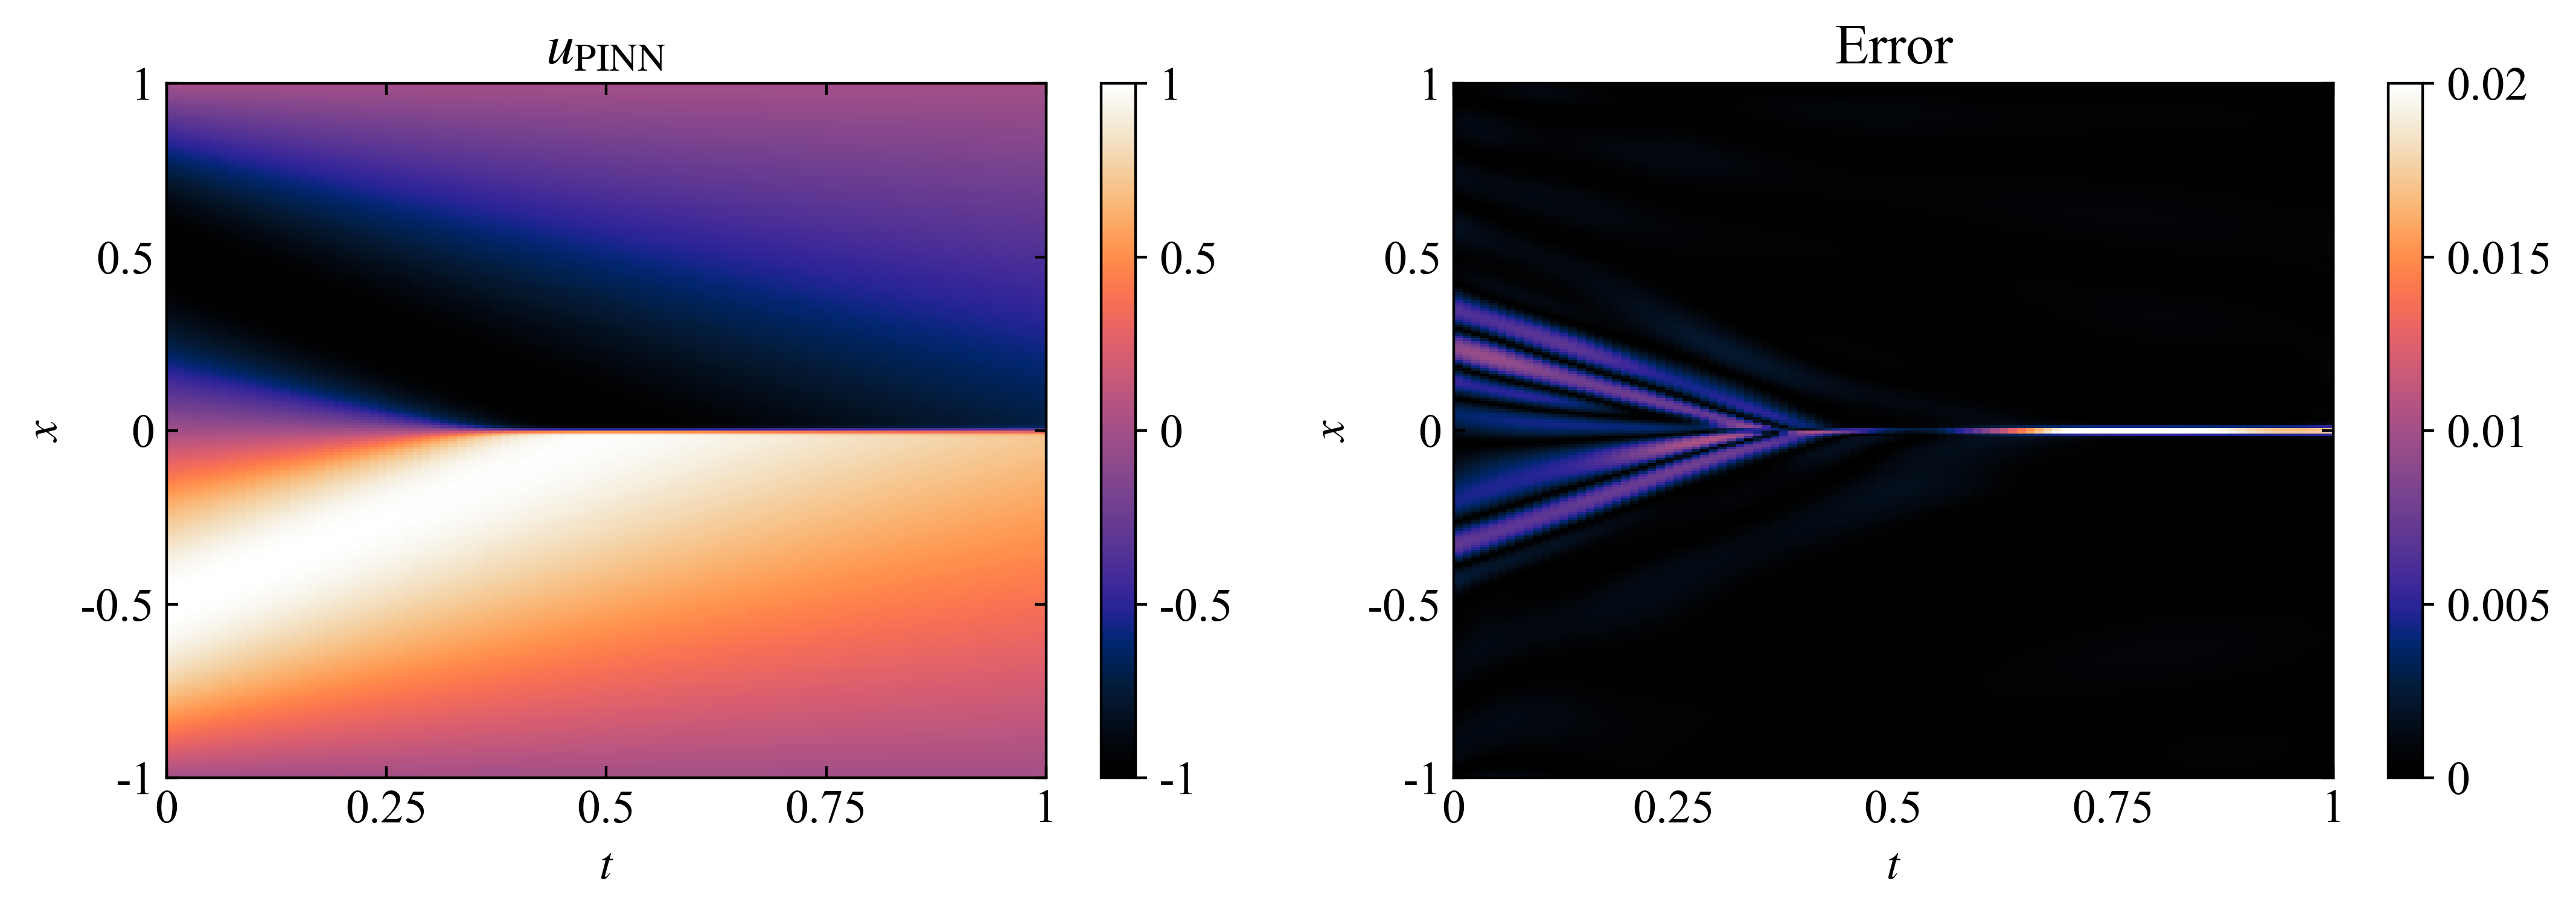

L1 error: 0.0008506777399388999
L2 relative error: 0.0030195936774198356


In [11]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import colormaps as cmaps
#from colormaps import *

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'  # 수학 표현에 대한 글꼴 설정
mpl.rcParams['font.size'] = 14  # 기본 글꼴 크기 설정
mpl.rcParams['figure.dpi'] = 400

cmap = cmaps.torch  # 기본 컬러맵 설정
#cmap = cmap_colormap_2_whitecenter

def no_dot_if_int(x, pos):
    if float(x).is_integer():
        return f"{int(x)}"
    else:
        return f"{x:g}"

error = np.abs(exact - prediction)

plt.figure(figsize=(11,4))

# 2. Prediction
plt.subplot(1,2,1)
im2 = plt.imshow(prediction.T, aspect='auto', extent=[0,1,-1,1], origin='lower', cmap=cmap, vmin=-1, vmax=1)
plt.title('$u_{\\mathrm{{PINN}}}$')
plt.xlabel('$t$', fontsize=14,)
plt.ylabel('$x$', fontsize=14,)
plt.xticks(np.linspace(0, 1, 5), [f'{i/4:.2f}' for i in range(5)])
plt.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
plt.colorbar(im2, ticks=np.linspace(1, -1, 5))

# 3. Absolute Error
plt.subplot(1,2,2)
im3 = plt.imshow(error.T, aspect='auto', extent=[0,1,-1,1], origin='lower', cmap=cmap, vmin=0, vmax=.02)
plt.title('Error')
plt.xlabel('$t$', fontsize=14,)
plt.ylabel('$x$', fontsize=14,)
plt.xticks(np.linspace(0, 1, 5), [f'{i/4:.2f}' for i in range(5)])
plt.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
plt.colorbar(im3, ticks=np.linspace(0, .02, 5))

formatter = FuncFormatter(no_dot_if_int)

for ax in plt.gcf().axes:
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

print('L1 error:', np.mean(error))
print('L2 relative error:', np.linalg.norm(error) / np.linalg.norm(exact))

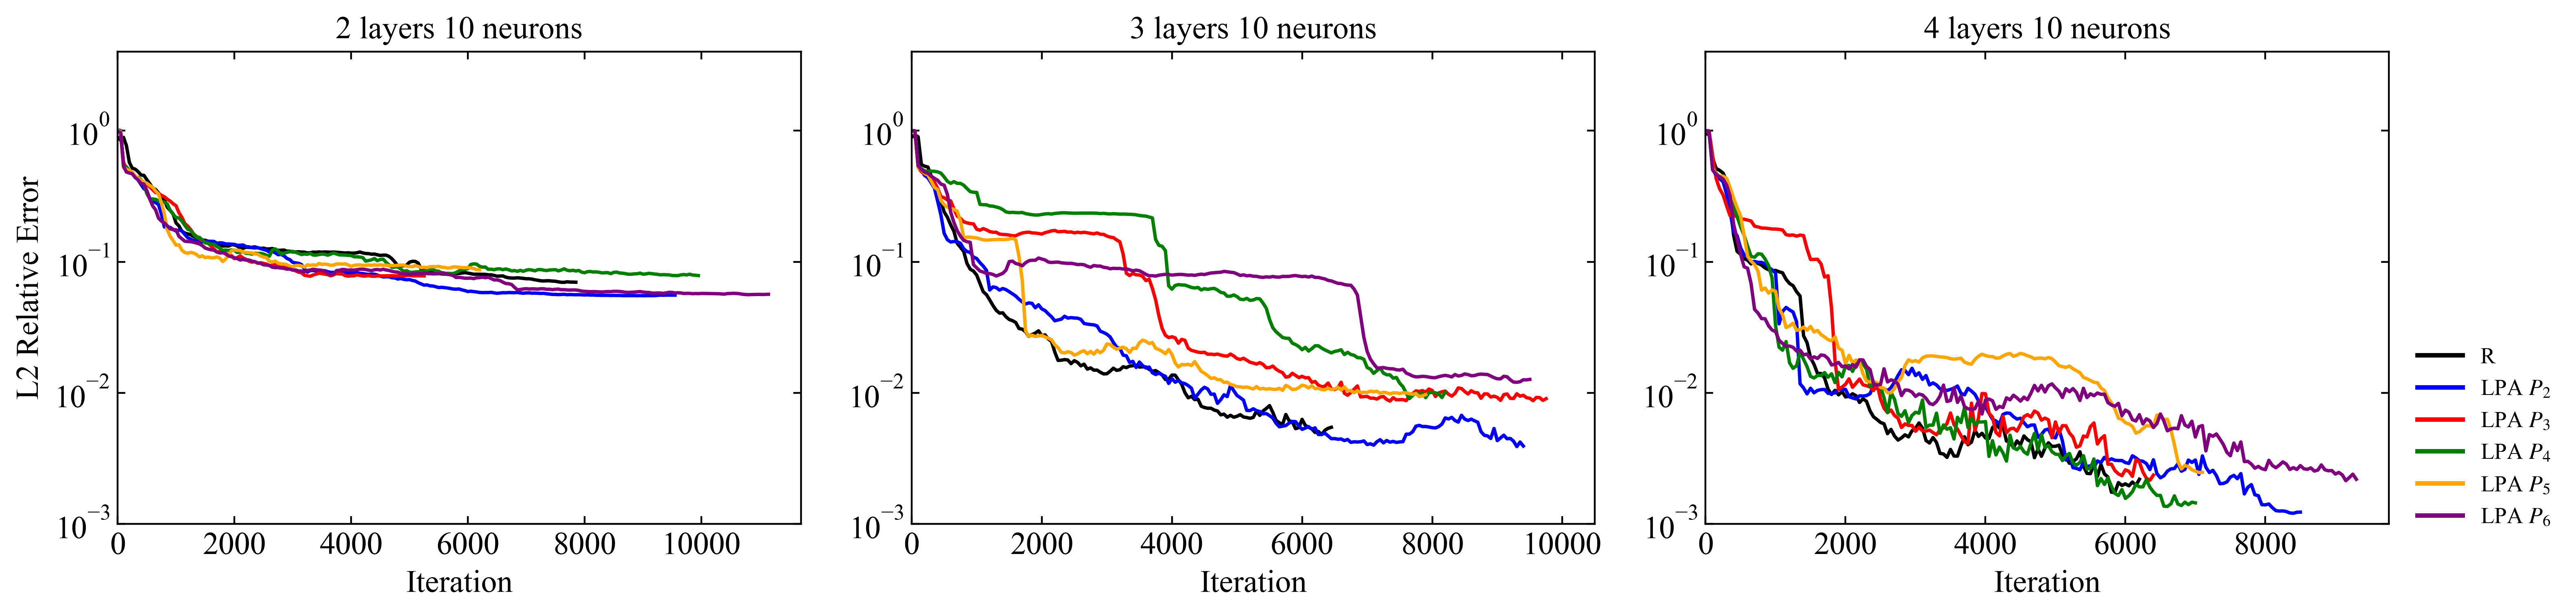

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from matplotlib.lines import Line2D  # ★ 추가

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'  # 수학 표현에 대한 글꼴 설정
mpl.rcParams['font.size'] = 14  # 기본 글꼴 크기 설정
mpl.rcParams['figure.dpi'] = 400


# 모델 trial 설정
model_keys = {
    'R': {'trials': range(0, 10), 'color': 'black'},
    #'ADAF':{'trials': range(0, 10), 'color': 'red'},
    'LPA $P_{2}$': {'trials': range(0, 10), 'color': 'blue'},
    'LPA $P_{3}$': {'trials': range(10, 20), 'color': 'red'},
    'LPA $P_{4}$': {'trials': range(20, 30), 'color': 'green'},
    'LPA $P_{5}$': {'trials': range(30, 40), 'color': 'orange'},
    'LPA $P_{6}$': {'trials': range(40, 50), 'color': 'purple'},
    #'LPA+gPINN': {'trials': range(10, 20), 'color': 'red'},
}

# 네트워크 구성 설정
configs = [(2, 10), (3, 10), (4, 10)]
#configs = [(2,20), (2,40), (2,60), (4,20), (4,40), (4,60)]

fig, axes = plt.subplots(1, len(configs), figsize=(5*len(configs), 4))

for ax, (layers, neurons) in zip(axes, configs):
    for model_name, setting in model_keys.items():
        best_l2 = np.inf
        best_l2_history = None

        for trial in setting['trials']:
            if model_name == 'R':
                fname = f'./results/acc_hist_{layers}_{neurons}_R_{trial}.txt'
            elif model_name == 'ADAF':
                fname = f'./results/acc_hist_{layers}_{neurons}_ADAF_{trial}.txt'
            else:
                fname = f'./results/acc_hist_{layers}_{neurons}_LPA_{trial}.txt'

            if not os.path.exists(fname):
                continue

            try:
                loss = np.loadtxt(fname, delimiter=',')
                if loss.ndim == 2 and loss.shape[1] >= 2:
                    l2_history = loss[:, 1]
                    final_l2 = l2_history[-1]
                    if final_l2 < best_l2:
                        best_l2 = final_l2
                        best_l2_history = l2_history
            except Exception as e:
                print(f"Error reading {fname}: {e}")

        if best_l2_history is not None:
            iterations = np.arange(len(best_l2_history)) * 50  # 🔥 50배 곱하기
            ax.plot(iterations, best_l2_history, label=model_name,
                    color=setting['color'], linestyle='-')

    ax.set_title(f'{layers} layers {neurons} neurons', fontsize=14)
    ax.set_xlabel('Iteration')
    ax.set_xlim(0,)
    if (layers, neurons) == (3,10):
        ax.set_xlim(0,10000+500)
    ax.set_ylim(1e-3,4)
    ax.set_yscale('log')
    ax.grid(False)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
    ax.tick_params(axis='both', which='minor', labelsize=14, left=False)
    ax.legend(fontsize=10, loc='best', frameon=False, ncol=1).remove()

axes[0].set_ylabel('L2 Relative Error')

# 1) 기본 subplot 레이아웃은 유지
fig.tight_layout()

# 2) 공통 legend를 figure 오른쪽 바깥에 배치
legend_handles = [
    Line2D([0], [0], lw=2, color=setting['color'], label=model_name)
    for model_name, setting in model_keys.items()
]

fig.legend(handles=legend_handles,
           loc='center',          # anchor 기준 왼쪽 정렬
           bbox_to_anchor=(1.025, 0.3), # (x,y) 좌표: figure 오른쪽 바깥 중앙
           fontsize=10,
           frameon=False,
           ncol=1)

plt.show()

In [ ]:
import numpy as np
import os

# 기본 설정
result_dir = './results'
trial = 0
keys = ['R', 'LPA']
configs = [(2,20),(2,40),(2,60),(3,10),(4,20),(4,40),(4,60)]

results = {key: [] for key in keys}

for key in keys:
    for layers, neurons in configs:
        acc_file = f'{result_dir}/acc_hist_{layers}_{neurons}_{key}_{trial}.txt'
        time_file = f'{result_dir}/cal_time_{layers}_{neurons}_{key}_{trial}.txt'

        # Accuracy
        if os.path.exists(acc_file):
            acc_hist = np.loadtxt(acc_file, delimiter=',')
            final_L1 = acc_hist[-1, 0]
            final_L2 = acc_hist[-1, 1]
            epochs = acc_hist.shape[0]*50
        else:
            final_L1, final_L2, epochs = None, None, None
            print(f'⚠️ Missing acc_hist: {acc_file}')

        # Time
        if os.path.exists(time_file):
            time_data = np.loadtxt(time_file, delimiter=',')
            total_time = np.sum(time_data)
            time_per_epoch = total_time / epochs if epochs else None
        else:
            total_time, time_per_epoch = None, None
            print(f'⚠️ Missing cal_time: {time_file}')

        results[key].append((layers, neurons, final_L1, final_L2, epochs, total_time, time_per_epoch))

# 출력
print(f"\n🔎 Final Results with Time per Epoch (trial = {trial})\n")
print(f"{'Key':<5} {'Layers':>6} {'Neurons':>8} {'L1 Error':>12} {'L2 Rel Error':>15} {'Epochs':>8} {'Total Time(s)':>15} {'Time/Epoch(s)':>15}")
print("-" * 95)

for key in keys:
    for l, n, l1, l2, e, t, tpe in results[key]:
        if l1 is not None and t is not None:
            print(f"{key:<5} {l:>6} {n:>8} {l1:>12.3e} {l2:>15.3e} {e:>8} {t:>15.2f} {tpe:>15.4f}")
        elif l1 is None and t is None:
            print(f"{key:<5} {l:>6} {n:>8} {'[acc+time missing]':>75}")
        elif l1 is None:
            print(f"{key:<5} {l:>6} {n:>8} {'[acc missing]':>35} {t:>15.2f} {'?':>15}")
        elif t is None:
            print(f"{key:<5} {l:>6} {n:>8} {l1:>12.3e} {l2:>15.3e} {e:>8} {'[time missing]':>15} {'?':>15}")



🔎 Final Results with Time per Epoch (trial = 0)

Key   Layers  Neurons     L1 Error    L2 Rel Error   Epochs   Total Time(s)   Time/Epoch(s)
-----------------------------------------------------------------------------------------------
R          2       20    4.679e-03       1.932e-02    11350          762.85          0.0672
R          2       40    7.736e-03       3.914e-02     5950         1014.87          0.1706
R          2       60    1.503e-02       7.114e-02     6250         1235.10          0.1976
R          3       10    5.770e-03       4.599e-02     5500          136.19          0.0248
R          4       20    4.816e-04       1.572e-03     4850          750.11          0.1547
R          4       40    2.576e-04       1.023e-03     6550         2129.26          0.3251
R          4       60    7.778e-04       3.509e-03     7350         3503.45          0.4767
LPA        2       20    1.762e-03       1.014e-02    14450          371.82          0.0257
LPA        2       40    3

In [6]:
import numpy as np
import os

# 기본 설정
result_dir = './results'
keys = ['R', 'LPA']
configs = [(2,10),(3,10),(4,10)]#[(2,20), (2,40), (2,60), (3,10), (4,20), (4,40), (4,60)]

# 최저 L2 결과를 저장할 딕셔너리 초기화
# best_results[key][(layers, neurons)] = {
#     'trial': int,
#     'final_L1': float,
#     'final_L2': float,
#     'epochs': int,
#     'total_time': float,
#     'time_per_epoch': float
# }
best_results = {key: {} for key in keys}
for key in keys:
    for layers, neurons in configs:
        # 초기값: L2 무한대로 설정
        best = {
            'trial': None,
            'final_L1': None,
            'final_L2': np.inf,
            'epochs': None,
            'total_time': None,
            'time_per_epoch': None
        }

        # trial 0부터 9까지 반복
        for trial in range(0,10):
            acc_file = f'{result_dir}/acc_hist_{layers}_{neurons}_{key}_{trial}.txt'
            time_file = f'{result_dir}/cal_time_{layers}_{neurons}_{key}_{trial}.txt'

            # Accuracy 읽기
            if os.path.exists(acc_file):
                acc_hist = np.loadtxt(acc_file, delimiter=',')
                final_L1 = acc_hist[-1, 0]
                final_L2 = acc_hist[-1, 1]
                epochs = acc_hist.shape[0] * 50
            else:
                # 파일이 없으면 건너뜀
                continue

            # Time 읽기
            if os.path.exists(time_file):
                time_data = np.loadtxt(time_file, delimiter=',')
                total_time = np.sum(time_data)
                time_per_epoch = total_time / epochs if epochs else None
            else:
                # 시간 파일 없으면 None 처리
                total_time = None
                time_per_epoch = None

            # 현재 trial이 best L2 보다 좋으면 갱신
            if final_L2 is not None and final_L2 < best['final_L2']:
                best.update({
                    'trial': trial,
                    'final_L1': final_L1,
                    'final_L2': final_L2,
                    'epochs': epochs,
                    'total_time': total_time,
                    'time_per_epoch': time_per_epoch
                })

        best_results[key][(layers, neurons)] = best

# 출력
print("\n🔎 Best Results over trials 0–9 (lowest L2)\n")
header = f"{'Key':<5} {'Layers':>6} {'Neurons':>8} {'Trial':>6} {'L1 Error':>12} {'L2 Rel Error':>15} {'Epochs':>8} {'Total Time(s)':>15} {'Time/Epoch(s)':>15}"
print(header)
print("-" * len(header))

for key in keys:
    for (layers, neurons), res in best_results[key].items():
        if res['trial'] is not None:
            print(f"{key:<5} {layers:>6} {neurons:>8} {res['trial']:>6} "
                  f"{res['final_L1']:>12.3e} {res['final_L2']:>15.3e} "
                  f"{res['epochs']:>8} {res['total_time']:>15.2f} {res['time_per_epoch']:>15.4f}")
        else:
            print(f"{key:<5} {layers:>6} {neurons:>8} {'[no data]':>67}")



🔎 Best Results over trials 0–9 (lowest L2)

Key   Layers  Neurons  Trial     L1 Error    L2 Rel Error   Epochs   Total Time(s)   Time/Epoch(s)
--------------------------------------------------------------------------------------------------
R          2       10      0    2.027e-02       6.990e-02     7900          135.69          0.0172
R          3       10      5    1.377e-03       5.468e-03     6500          161.64          0.0249
R          4       10      5    7.739e-04       2.195e-03     6250          206.92          0.0331
LPA        2       10      4    1.503e-02       5.571e-02     9600          340.83          0.0355
LPA        3       10      1    1.407e-03       3.935e-03     9450          184.87          0.0196
LPA        4       10      1    4.214e-04       1.233e-03     8550          450.56          0.0527


In [7]:
8.000e-02

0.08

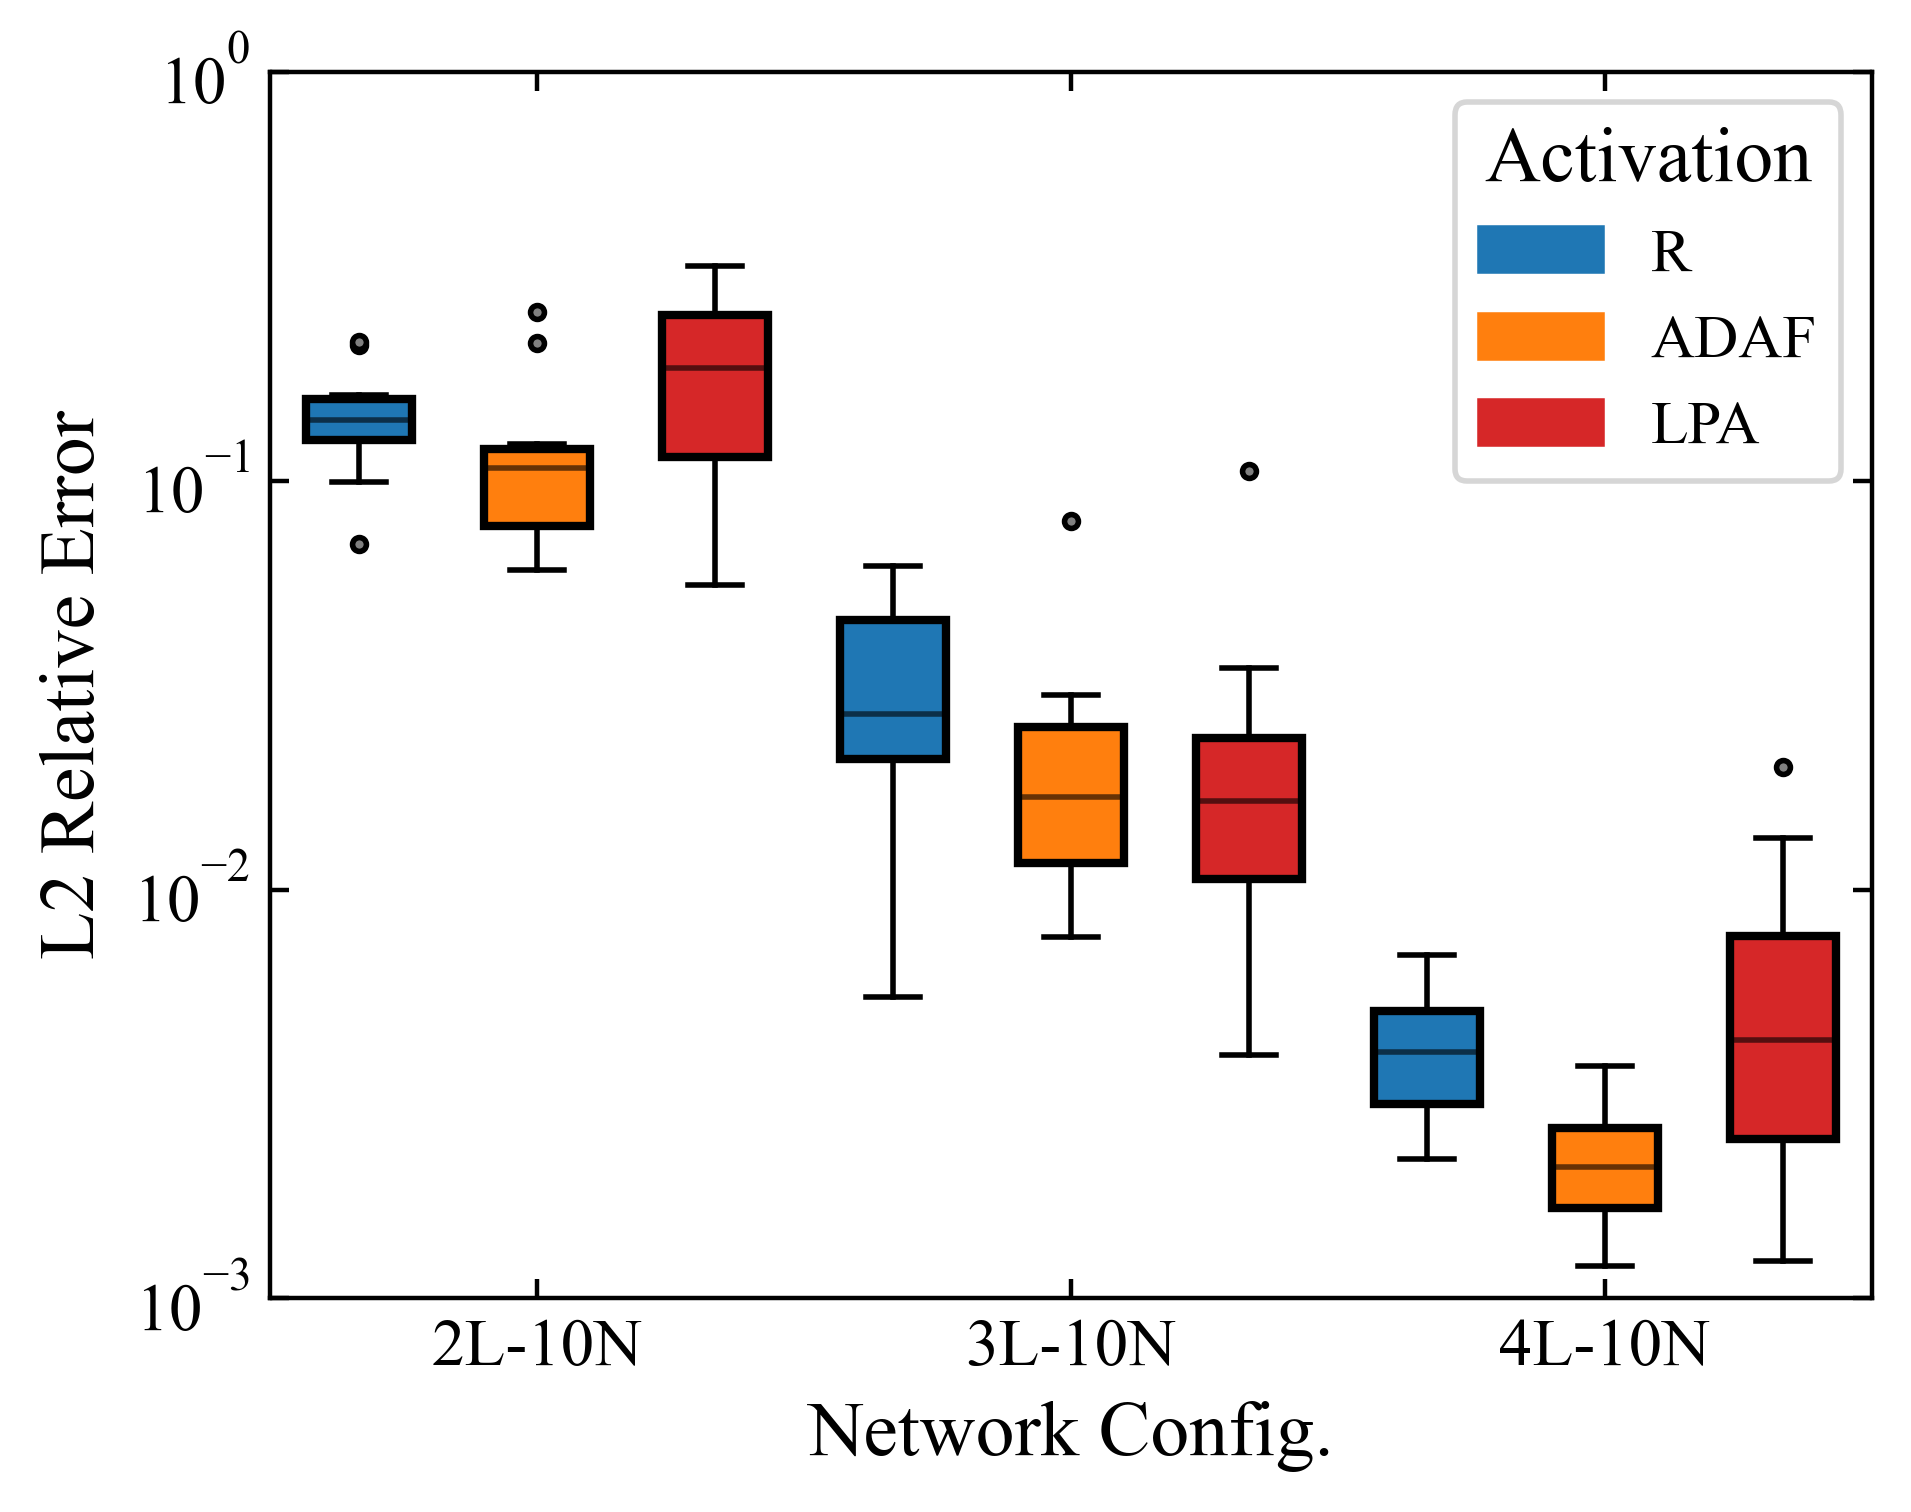

In [9]:

import os
import numpy as np
import matplotlib.pyplot as plt
from pinn_utils import Build_PINN  # PINN 생성 함수

# 기본 설정
result_dir = './results'
keys = ['R', 'ADAF', 'LPA']
configs = [(2, 10), (3, 10), (4, 10)]

# 도메인 경계 설정
lb = np.array([0.0, -1.0], dtype=np.float32)
ub = np.array([1.0, 1.0], dtype=np.float32)

# 결과 저장
errors = {key: {} for key in keys}

# 데이터 수집
for key in keys:
    for layers, neurons in configs:
        L2_list = []
        for trial in range(10):
            acc_file = f'{result_dir}/acc_hist_{layers}_{neurons}_{key}_{trial}.txt'
            if os.path.exists(acc_file):
                acc_hist = np.loadtxt(acc_file, delimiter=',')
                L2_error = acc_hist[-1, 1]
                L2_list.append(L2_error)
        errors[key][(layers, neurons)] = L2_list if L2_list else None

# 📊 단일 그래프에 세 key 비교
fig, ax = plt.subplots(figsize=(5, 4))

all_data = []
xticks = []
xtick_positions = []
position_counter = 1
box_colors = []

color_map = {'R': 'C0', 'ADAF': 'C1', 'LPA': 'C3'}

for (layers, neurons) in configs:
    # 파라미터 수 계산
    pinn = Build_PINN(lb, ub, layers, neurons, 'R')  # 아무 키로든 param 수 동일
    param_count = pinn.model.count_params()
    label = f"{layers}L-{neurons}N\n({param_count} params)"

    for key in keys:
        cfg_errors = errors[key].get((layers, neurons))
        if cfg_errors:
            all_data.append(cfg_errors)
            xticks.append(label if key == 'R' else "")  # 첫번째 key에만 label 부여
            xtick_positions.append(position_counter)
            box_colors.append(color_map[key])
            position_counter += 1
        else:
            all_data.append([])
            xticks.append(label if key == 'R' else "")
            xtick_positions.append(position_counter)
            box_colors.append(color_map[key])
            position_counter += 1

# boxplot
boxprops = dict(linewidth=1.5)
bp = ax.boxplot(
    all_data,
    positions=xtick_positions,
    widths=0.6,
    patch_artist=True,
    showmeans=False,
    meanline=False,
    showfliers=True,
    boxprops=boxprops,
    medianprops=dict(color='black', linewidth=1, alpha=0.6),
    flierprops=dict(marker='.', markerfacecolor='grey', markersize=5,
                    linestyle='none', markeredgecolor='black')
)

# 색상 적용
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(1.0)

# xtick 설정
group_width = len(keys)
xtick_centers = [np.mean(xtick_positions[i:i + group_width]) for i in range(0, len(xtick_positions), group_width)]
xtick_labels = [f"{cfg[0]}L-{cfg[1]}N" for cfg in configs]
ax.set_xticks(xtick_centers)
ax.set_xticklabels(xtick_labels)

# log-scale 및 labeling
ax.set_yscale('log')
ax.set_ylim(0.001, 1)
ax.set_xlabel("Network Config.")
ax.set_ylabel("L2 Relative Error")
ax.grid(False)

# legend
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[k], alpha=1.0) for k in keys]
ax.legend(legend_handles, keys, title="Activation", fontsize=11)

# tick 스타일
plt.tick_params(axis='both', which='major', direction='in', labelsize=12, top=True, right=True)
plt.tick_params(axis='both', which='minor', direction='in', labelsize=12, left=False, right=False)

plt.tight_layout()
plt.show()


In [ ]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
os.environ["CUDA_VISIBLE_DEVICES"]="100"

import pickle
import tensorflow as tf
#tf.keras.utils.disable_interactive_logging()

import numpy as np
import matplotlib.pyplot as plt

from time import time
from pinn_utils import *
from multiprocessing import Pool


def run(trial, condition):
    # Model keyword
    key = 'LPA'
    num_hidden_layers=condition[0]
    num_neurons_per_layer=condition[1]
    
    DTYPE = 'float32'
    loss_dict = {
        'loss_BC_coeff': tf.constant([1e0, 1e0]),
        'loss_PDE_coeff': tf.constant(1e0),
        'loss_IC_coeff': tf.constant(1e0),
        'loss_gPINN_coeff': tf.constant(1e-4)  # or 1e-4
    }


    ## Time Stepping Hyperparameters
    time_stepping_number = 1
    time_marching_constant = 1

    # Material Properties
    viscosity = .01/np.pi
    time_concern = 1.
    L = 1.

    # Set boundary
    tmin = 0.
    tmax = time_concern
    xmin = -L
    xmax = L

    # Properties_dict
    properties = {
        'viscosity':viscosity,  
        'L':L,
        'time_concern':time_concern,
        'time_stepping_number':time_stepping_number,
        'time_marching_constant':time_marching_constant,
        'tmin':tmin,
        'tmax':time_concern,
        'xmin':xmin,
        'xmax':L,
        }

    # Set number of data points
    N_0 = 200
    N_b = 200
    N_r = 10000

    #Model construction
    lb = tf.constant([tmin, xmin], dtype=DTYPE)
    ub = tf.constant([tmax/time_marching_constant, xmax], dtype=DTYPE)
    pinn = Build_PINN(lb, ub, num_hidden_layers, num_neurons_per_layer, key)
    pinn.model.summary()
    tf.keras.utils.disable_interactive_logging()
    del solver


def run_upper(trial):
    condition_set = [(3,10)]
    #condition_set = [(2,10),(3,10),(4,10)]
    #condition_set = [(2,20),(2,40),(2,60),(4,20),(4,40),(4,60)]
    for condition in condition_set:
        run(trial, condition)    
    

if __name__== '__main__':
    p = Pool(processes=2)
    p.map(run_upper, range(0,2))